In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [3]:
df = sns.load_dataset("penguins")

In [4]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Data cleaning and preprocessing 

In [5]:
df.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [7]:
df.drop_duplicates(inplace = True, ) #keep first row and drop duplicated rows

In [8]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [9]:
df.dropna(inplace = True) #dropping rows with missing values

In [10]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [11]:
# X : input data
# y : target vector
y = df.species

In [12]:
X = df.drop(["species"], axis = "columns")

In [13]:
X

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...
338,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Biscoe,45.2,14.8,212.0,5200.0,Female


In [14]:
y

0      Adelie
1      Adelie
2      Adelie
4      Adelie
5      Adelie
        ...  
338    Gentoo
340    Gentoo
341    Gentoo
342    Gentoo
343    Gentoo
Name: species, Length: 333, dtype: object

one-hot encoding of categorical variables 

In [15]:
X.dtypes

island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [16]:
cols_categorical = X.columns[X.dtypes == "object"].tolist()
cols_categorical

['island', 'sex']

In [19]:
preprocessor = ColumnTransformer(
    [
        ("categorical", OneHotEncoder(sparse_output = False), cols_categorical),
    ],
    verbose_feature_names_out = False, remainder = "passthrough",
) #transforming columns

In [20]:
preprocessor.set_output(transform = "pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(sparse_output=False),
                                 ['island', 'sex'])],
                  verbose_feature_names_out=False)

In [21]:
X_ohe = preprocessor.fit_transform(X)

X_ohe

,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0.0,0.0,1.0,0.0,1.0,39.1,18.7,181.0,3750.0
1,0.0,0.0,1.0,1.0,0.0,39.5,17.4,186.0,3800.0
2,0.0,0.0,1.0,1.0,0.0,40.3,18.0,195.0,3250.0
4,0.0,0.0,1.0,1.0,0.0,36.7,19.3,193.0,3450.0
5,0.0,0.0,1.0,0.0,1.0,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...,...,...,...
338,1.0,0.0,0.0,1.0,0.0,47.2,13.7,214.0,4925.0
340,1.0,0.0,0.0,1.0,0.0,46.8,14.3,215.0,4850.0
341,1.0,0.0,0.0,0.0,1.0,50.4,15.7,222.0,5750.0
342,1.0,0.0,0.0,1.0,0.0,45.2,14.8,212.0,5200.0


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size = 0.2, random_state = 42, stratify = y)

In [23]:
clf = DecisionTreeClassifier(random_state = 123) #decision tree classifier

clf.fit(X_train, y_train)  #fitting the model to the training set

DecisionTreeClassifier(random_state=123)

In [24]:
#evaluating model performance 

y_pred = clf.predict(X_test) #prediction on test set

accuracy = accuracy_score(y_test, y_pred) #calculating accuracy
print(f"Accuracy: {accuracy :2f}")

report = classification_report(y_test, y_pred) #generating classification report
print("Classification Report : \n", report)

Accuracy: 0.955224
Classification Report : 
               precision    recall  f1-score   support

      Adelie       0.93      0.97      0.95        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.96      0.96      0.96        67



hyperparamter tuning with gridsearchcv

In [26]:
param_grid = {   #hyperparamters to search
    'criterion' : ['gini', 'entropy'],  #criterias 
    'max_depth' : [None, 5, 10, 15], #max no of nodes
    'min_samples_split' : [2, 5, 10], #sample spilts
    'min_samples_leaf' : [1, 2, 4] #max no of leaf nodes
}

grid_search = GridSearchCV(estimator = clf, param_grid = param_grid, cv = 5, n_jobs = -1) #initializing gridsearchcv

grid_search.fit(X_train, y_train) #fitting grid search to data

best_params = grid_search.best_params_  #best parameters 
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [28]:
# final model

best_clf = DecisionTreeClassifier(**best_params, random_state = 123) #new classifier with best hyperparamaters

best_clf.fit(X_train, y_train) #fitting best model to the data

y_pred_optimized = best_clf.predict(X_test) #predictions on test set

accuracy_optimized = accuracy_score(y_test, y_pred_optimized) #accuracy score after hyperparameter
print(f"Accuracy (Optimized): {accuracy_optimized:.5f}")

report = classification_report(y_test, y_pred_optimized) #classification report
print("Classification Report:\n", report)



Accuracy (Optimized): 0.95522
Classification Report:
               precision    recall  f1-score   support

      Adelie       0.93      0.97      0.95        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.96      0.96      0.96        67



In [30]:
y_pred_optimized = grid_search.predict(X_test) #predictions on test set

accuracy_optimized = accuracy_score(y_test, y_pred_optimized) #accuracy after hpt
print(f"Accuracy (Optimized) : {accuracy_optimized:.5f}")

report = classification_report(y_test, y_pred_optimized) #generating classification report
print("Classification Report:\n", report)

Accuracy (Optimized) : 0.95522
Classification Report:
               precision    recall  f1-score   support

      Adelie       0.93      0.97      0.95        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.96      0.96      0.96        67



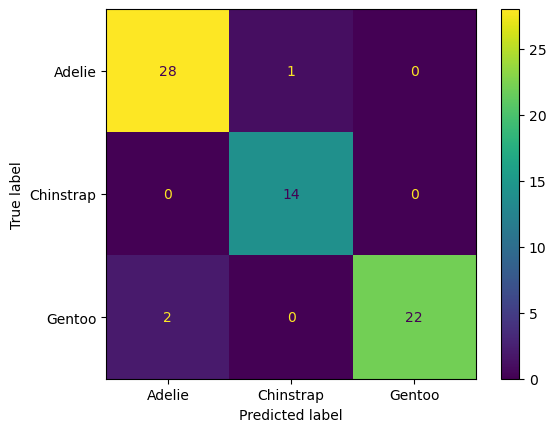

In [44]:

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimized); #displays cm
plt.show()